In [5]:
import numpy as np
import pandas as pd

# Update the file name/path to match the exact name in your folder
# Example: 'Real_Estate_Sales_2001-2021_GL.csv' or 'Real_Estate_Sales_200).csv'
file_path = "Real_Estate_Sales_200).csv"

# Load with low_memory=False to handle mixed column types cleanly
df = pd.read_csv(file_path, low_memory=False)

print("Dataset Dimensions:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst 3 Rows:")
print(df.head(3))

Dataset Dimensions: (999999, 14)

Column Names:
['Serial Number', 'List Year', 'Date Recorded', 'Town', 'Address', 'Assessed Value', 'Sale Amount', 'Sales Ratio', 'Property Type', 'Residential Type', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13']

First 3 Rows:
   Serial Number  List Year Date Recorded     Town          Address  \
0        2020348       2020    09/13/2021  Ansonia  230 WAKELEE AVE   
1          20002       2020    10/02/2020  Ashford  390 TURNPIKE RD   
2         210317       2021    07/05/2022     Avon  53 COTSWOLD WAY   

   Assessed Value  Sale Amount  Sales Ratio Property Type Residential Type  \
0        150500.0     325000.0       0.4630    Commercial              NaN   
1        253000.0     430000.0       0.5883   Residential    Single Family   
2        329730.0     805000.0       0.4096   Residential    Single Family   

   Unnamed: 10  Unnamed: 11  Unnamed: 12  Unnamed: 13  
0          NaN          NaN          NaN          NaN  
1          NaN 

In [6]:
# 1. Define the 10 target features
features = [
    "Serial Number",
    "List Year",
    "Date Recorded",
    "Town",
    "Address",
    "Assessed Value",
    "Sale Amount",
    "Sales Ratio",
    "Property Type",
    "Residential Type",
]

# 2. Drop trailing unneeded columns and filter complete price records
df_clean = df[features].dropna(subset=["Sale Amount", "Assessed Value"]).copy()

# 3. Sample 25,000 rows for smooth computation and visualization
df_midterm = df_clean.sample(n=25000, random_state=42).reset_index(drop=True)

# 4. Save the raw working file
df_midterm.to_csv("real_estate_midterm_raw.csv", index=False)

print("Working Dataset Shape:", df_midterm.shape)
print("\nMissing Values per Column:")
print(df_midterm.isnull().sum())
print("\nFirst 3 Rows:")
df_midterm.head(3)

Working Dataset Shape: (25000, 10)

Missing Values per Column:
Serial Number          0
List Year              0
Date Recorded          0
Town                   0
Address                2
Assessed Value         0
Sale Amount            0
Sales Ratio            0
Property Type       9469
Residential Type    9770
dtype: int64

First 3 Rows:


,Serial Number,List Year,Date Recorded,Town,Address,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type
0,18364,2018,09/03/2019,North Haven,67 MONTOWESE AVE,148960.0,202000.0,0.737400,Single Family,Single Family
1,21218,2021,04/25/2022,Bethel,526 COPPER SQUARE DRIVE,212730.0,382000.0,0.556800,Residential,Condo
2,80487,2008,07/31/2009,Fairfield,245 UNQUOWA ROAD #109,206220.0,325000.0,0.634523,Condo,Condo


In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Work on a copy of the sampled dataset
df_proc = df_midterm.copy()

# 1. Fill missing Address with a placeholder
df_proc["Address"] = df_proc["Address"].fillna("Unknown Address")

# 2. Impute missing Property Type and Residential Type
# For records where Residential Type exists but Property Type is NaN, it's Residential
df_proc.loc[
    df_proc["Residential Type"].notnull()
    & df_proc["Property Type"].isnull(),
    "Property Type",
] = "Residential"

# Impute remaining missing categorical values with explicit category names
df_proc["Property Type"] = df_proc["Property Type"].fillna("Unspecified")
df_proc["Residential Type"] = df_proc["Residential Type"].fillna(
    "Non-Residential"
)

# 3. Verify zero missing values remain
print("Missing values after imputation:")
print(df_proc.isnull().sum())

Missing values after imputation:
Serial Number       0
List Year           0
Date Recorded       0
Town                0
Address             0
Assessed Value      0
Sale Amount         0
Sales Ratio         0
Property Type       0
Residential Type    0
dtype: int64


In [8]:
# Convert Date Recorded to datetime
df_proc["Date Recorded"] = pd.to_datetime(
    df_proc["Date Recorded"], errors="coerce"
)
df_proc["Sale Year"] = df_proc["Date Recorded"].dt.year
df_proc["Sale Month"] = df_proc["Date Recorded"].dt.month

# Clean unrealistic price records (filter prices > 0 and reasonable sales ratios)
df_proc = df_proc[(df_proc["Sale Amount"] >= 2000) & (df_proc["Assessed Value"] > 0)]
df_proc = df_proc[(df_proc["Sales Ratio"] > 0.01) & (df_proc["Sales Ratio"] < 5.0)]

print("Dataset shape after outlier removal:", df_proc.shape)

Dataset shape after outlier removal: (24374, 12)


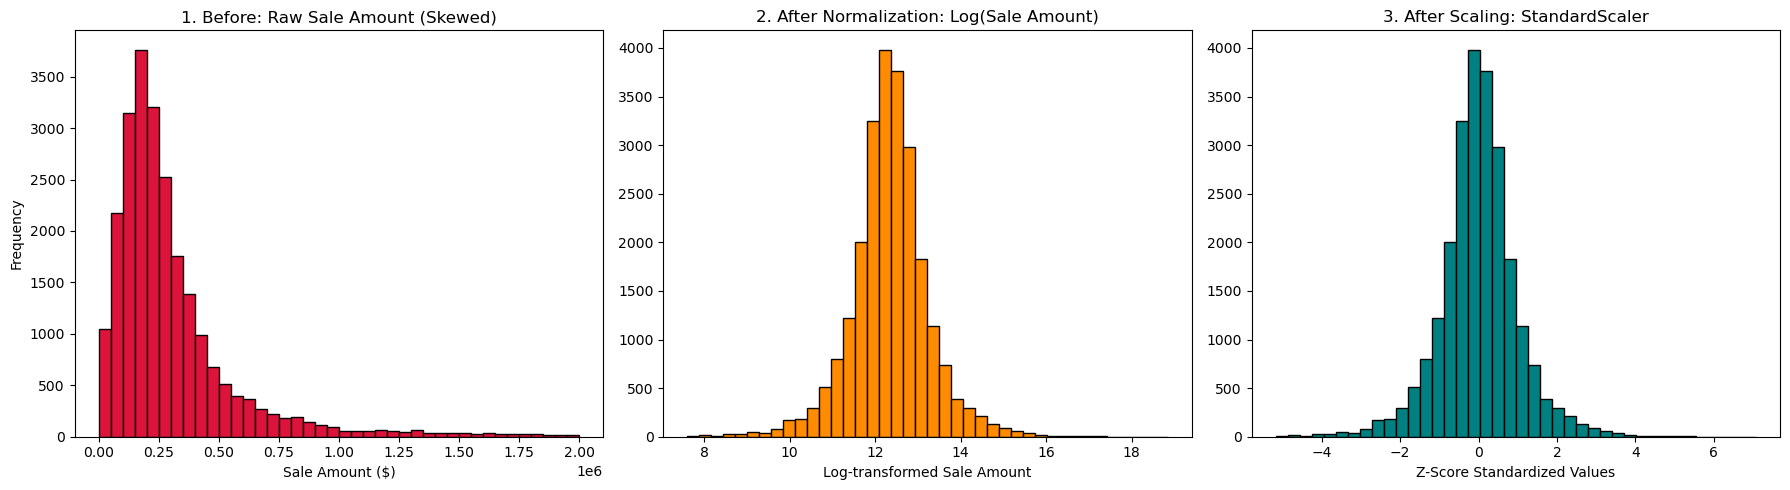

In [9]:
from sklearn.preprocessing import StandardScaler

# Compute log-transformed Sale Amount to fix heavy right skew
df_proc["Sale Amount_Log"] = np.log1p(df_proc["Sale Amount"])

# Standardize log-transformed features
scaler = StandardScaler()
df_proc["Sale Amount_Scaled"] = scaler.fit_transform(
    df_proc[["Sale Amount_Log"]]
)

# Matplotlib Before vs. After Distribution Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Raw Skewed Distribution
axes[0].hist(
    df_proc["Sale Amount"],
    bins=40,
    color="crimson",
    edgecolor="black",
    range=(0, 2000000),
)
axes[0].set_title("1. Before: Raw Sale Amount (Skewed)")
axes[0].set_xlabel("Sale Amount ($)")
axes[0].set_ylabel("Frequency")

# Plot 2: Log Normalized Distribution
axes[1].hist(
    df_proc["Sale Amount_Log"], bins=40, color="darkorange", edgecolor="black"
)
axes[1].set_title("2. After Normalization: Log(Sale Amount)")
axes[1].set_xlabel("Log-transformed Sale Amount")

# Plot 3: Standard Scaled Distribution
axes[2].hist(
    df_proc["Sale Amount_Scaled"], bins=40, color="teal", edgecolor="black"
)
axes[2].set_title("3. After Scaling: StandardScaler")
axes[2].set_xlabel("Z-Score Standardized Values")

plt.tight_layout()
plt.show()

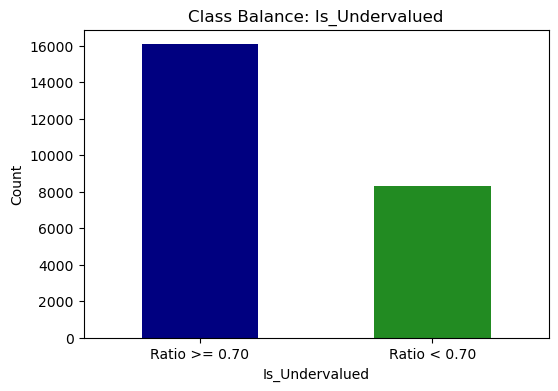

Columns after one-hot encoding:
['Serial Number', 'List Year', 'Date Recorded', 'Town', 'Address', 'Assessed Value', 'Sale Amount', 'Sales Ratio', 'Sale Year', 'Sale Month', 'Sale Amount_Log', 'Sale Amount_Scaled', 'Is_Undervalued', 'Property Type_Commercial', 'Property Type_Condo', 'Property Type_Four Family', 'Property Type_Industrial', 'Property Type_Residential', 'Property Type_Single Family', 'Property Type_Three Family', 'Property Type_Two Family', 'Property Type_Unspecified', 'Property Type_Vacant Land', 'Residential Type_Four Family', 'Residential Type_Non-Residential', 'Residential Type_Single Family', 'Residential Type_Three Family', 'Residential Type_Two Family']


In [10]:
# Create binary classification target for the rubric:
# Undervalued sale (1 if Sales Ratio < 0.70, else 0)
df_proc["Is_Undervalued"] = (df_proc["Sales Ratio"] < 0.70).astype(int)

# Visualizing class distribution
plt.figure(figsize=(6, 4))
df_proc["Is_Undervalued"].value_counts().plot(
    kind="bar", color=["navy", "forestgreen"]
)
plt.title("Class Balance: Is_Undervalued")
plt.xticks([0, 1], ["Ratio >= 0.70", "Ratio < 0.70"], rotation=0)
plt.ylabel("Count")
plt.show()

# One-hot encode Property Type and Residential Type
df_encoded = pd.get_dummies(
    df_proc,
    columns=["Property Type", "Residential Type"],
    drop_first=True,
    dtype=int,
)

print("Columns after one-hot encoding:")
print(df_encoded.columns.tolist())

In [11]:
# Save final pre-processed dataset for the submission
df_encoded.to_csv("cleaned_real_estate_midterm.csv", index=False)
print(
    "Pre-processed file saved successfully! Final shape:", df_encoded.shape
)

Pre-processed file saved successfully! Final shape: (24374, 28)


Data split completed: Training set = 17500 rows | Testing set (untouched) = 7500 rows


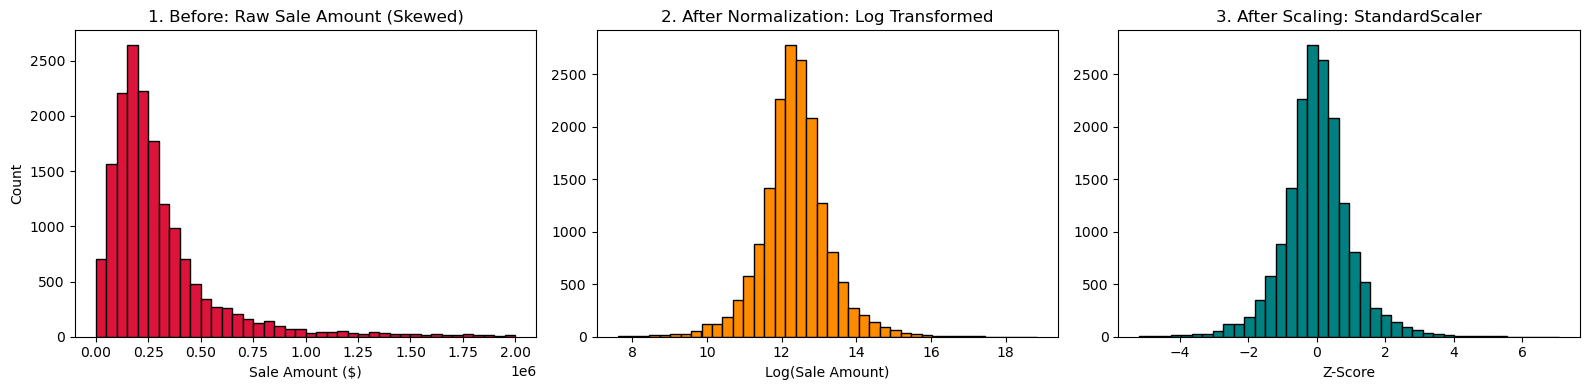

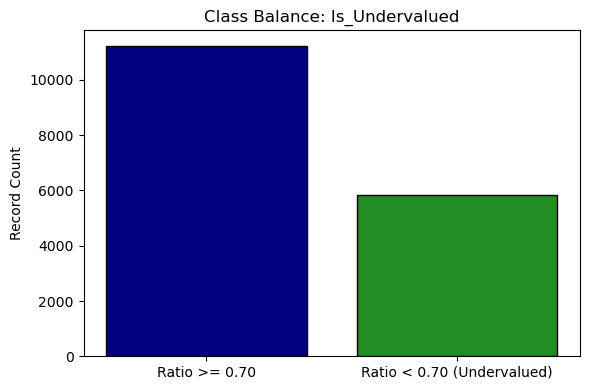

Pipeline complete. Cleaned training file saved to data/cleaned_train_data.csv


In [12]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Ensure directory for exports exists
os.makedirs("data", exist_ok=True)

# 1. Split the 25,000 sampled dataset: 70% Train / 30% Test
train_df, test_df = train_test_split(
    df_midterm, test_size=0.30, random_state=42
)

# Save the untouched testing data directly to storage
test_df.to_csv("data/raw_test_data.csv", index=False)
print(
    f"Data split completed: Training set = {len(train_df)} rows | Testing set (untouched) = {len(test_df)} rows"
)

# 2. Preprocessing & EDA exclusively on the Training Data
train_clean = train_df.copy()

# A. Impute missing categories
train_clean["Address"] = train_clean["Address"].fillna("Unknown Address")
train_clean.loc[
    train_clean["Residential Type"].notnull()
    & train_clean["Property Type"].isnull(),
    "Property Type",
] = "Residential"
train_clean["Property Type"] = train_clean["Property Type"].fillna(
    "Unspecified"
)
train_clean["Residential Type"] = train_clean["Residential Type"].fillna(
    "Non-Residential"
)

# B. Outlier filtering
train_clean = train_clean[
    (train_clean["Sale Amount"] >= 2000) & (train_clean["Assessed Value"] > 0)
]
train_clean = train_clean[
    (train_clean["Sales Ratio"] > 0.01) & (train_clean["Sales Ratio"] < 5.0)
]

# C. Normalization & Scaling (Sale Amount)
train_clean["Sale_Amount_Log"] = np.log1p(train_clean["Sale Amount"])
scaler = StandardScaler()
train_clean["Sale_Amount_Scaled"] = scaler.fit_transform(
    train_clean[["Sale_Amount_Log"]]
)

# D. Create binary target for class balancing (Undervalued vs Market Rate)
train_clean["Is_Undervalued"] = (train_clean["Sales Ratio"] < 0.70).astype(int)

# 3. Matplotlib Visualizations: Before & After
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(
    train_clean["Sale Amount"],
    bins=40,
    color="crimson",
    edgecolor="black",
    range=(0, 2000000),
)
axes[0].set_title("1. Before: Raw Sale Amount (Skewed)")
axes[0].set_xlabel("Sale Amount ($)")
axes[0].set_ylabel("Count")

axes[1].hist(
    train_clean["Sale_Amount_Log"], bins=40, color="darkorange", edgecolor="black"
)
axes[1].set_title("2. After Normalization: Log Transformed")
axes[1].set_xlabel("Log(Sale Amount)")

axes[2].hist(
    train_clean["Sale_Amount_Scaled"], bins=40, color="teal", edgecolor="black"
)
axes[2].set_title("3. After Scaling: StandardScaler")
axes[2].set_xlabel("Z-Score")

plt.tight_layout()
plt.savefig("distribution_comparison.png", dpi=300)
plt.show()

# 4. Matplotlib Class Balance Plot
plt.figure(figsize=(6, 4))
counts = train_clean["Is_Undervalued"].value_counts()
plt.bar(
    ["Ratio >= 0.70", "Ratio < 0.70 (Undervalued)"],
    counts.values,
    color=["navy", "forestgreen"],
    edgecolor="black",
)
plt.title("Class Balance: Is_Undervalued")
plt.ylabel("Record Count")
plt.tight_layout()
plt.savefig("class_balance.png", dpi=300)
plt.show()

# 5. One-Hot Encoding & Final Clean Data Export
train_encoded = pd.get_dummies(
    train_clean,
    columns=["Property Type", "Residential Type"],
    drop_first=True,
    dtype=int,
)
train_encoded.to_csv("data/cleaned_train_data.csv", index=False)
print("Pipeline complete. Cleaned training file saved to data/cleaned_train_data.csv")